In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd

Import numpy digunakan untuk hitung-hitungan angka. Gambar itu adalah kumpulan angka (matriks). Import matplotlib digunakan untuk tampilan gambar dan juga membuat grafik histogram. Import pandas digunakan untuk merapikan data statistik ke dalam tabel. Import opencv digunakan untuk membaca, mengubah warna dan memanipulasi gambar.

Kode di bawah ini berfungsi untuk membaca citra yang disimpan di variabel backup menggunakan OpenCV, mengubahnya ke dalam format grayscale dengan cv2.cvtColor, lalu plt.axis('off') untuk tidak menampilkan sumbu-x dan sumbu-y.

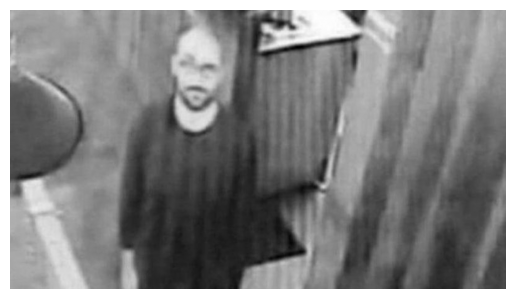

In [7]:
backup = cv2.imread('backup.jpg')
backup_gray = cv2.cvtColor(backup, cv2.COLOR_BGR2GRAY)
plt.imshow(backup_gray, cmap='gray')
plt.axis('off')
plt.show()


In [9]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype = np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val
    return canvas

mean = filter(backup_gray, 3, 'mean')
median = filter(backup_gray, 3, 'median')
modus = filter(backup_gray, 3, 'modus')


Apa Perbedaan Hasil dari Mean, Median dan Modus? Rata-rata (mean) untuk 
menghaluskan gambar, nilai tengah (median) untuk membersihkan bintik tajam tanpa 
merusak tepi, dan modus (mode) untuk menyeragamkan warna dominan.

Fungsi di bawah ini digunakan untuk menerapkan kernel matriks berbobot seperti kernel perbaikan citra (sharpening dan smoothing) atau deteksi tepi (Sobel, Prewitt, atau Robert) pada citra. 

Perbedaan Antara ke-3 metode tersebut, gambar dengan title smoothing tampak lebih halus, karena smoothing adalah penghalusan dengan meratakan piksel untuk melembutkan gambar. Sedangkan gambar dengan title sharpening tampak lebih tajam karena sharpening adalah penajaman dengan meningkatkan kontras untuk mempertegas detail. Sedangkan gambar dengan title smoothing + sharpening adalah perpaduan antara diperhalus dan juga dipertajam, sehingga gambar tampak normal.

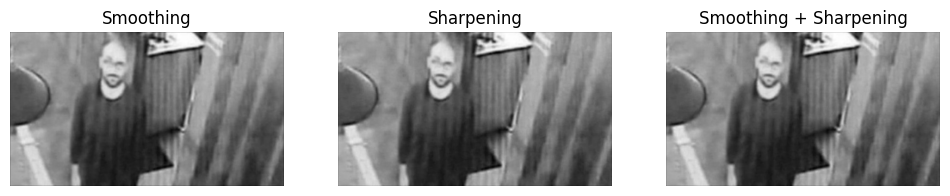

In [ ]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

kernelSmoothing = np.array([
     [1/10, 1/10, 1/10],
     [1/10, 1/5,  1/10],
     [1/10, 1/10, 1/10]
 ])

kernelSharpening = np.array([
     [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

smooth = convolution (backup_gray, kernelSmoothing)
sharp = convolution (backup_gray, kernelSharpening)
sm_plus_sh = smooth + sharp

plt.figure(figsize=(12,12))

plt.subplot(1,3,1)
plt.title("Smoothing")
plt.imshow(smooth, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Sharpening")
plt.imshow(sharp, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Smoothing + Sharpening")
plt.imshow(sm_plus_sh, cmap='gray')
plt.axis('off')

plt.show()

In [ ]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)


robertsX = np.array([
    [1,  0],
    [0, -1]
], dtype=np.float32)


robertsY = np.array([
    [ 0, 1],
    [-1, 0]
], dtype=np.float32)

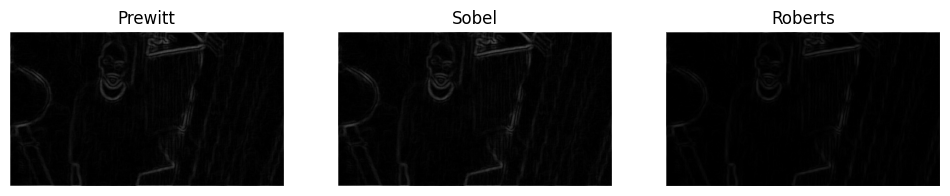

In [20]:
prewitt = edge(sm_plus_sh, prewittX, prewittY)
sobel = edge(sm_plus_sh, sobelX, sobelY)
robert = edge(sm_plus_sh, robertsX, robertsY)

plt.figure(figsize=(12,12))

plt.subplot(1,3,1)
plt.title("Prewitt")
plt.imshow(prewitt, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Sobel")
plt.imshow(sobel, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Roberts")
plt.imshow(robert, cmap='gray')
plt.axis('off')

plt.show()


In [22]:
ps = prewitt + sobel
pr = prewitt + robert
sr = sobel + robert
psr = prewitt + sobel + robert

In [24]:
def normalisasi(image):
    h, w = image.shape
    
    min_pixel = image[0, 0]
    max_pixel = image[0, 0]
    for i in range(h):
        for j in range(w):
            if image[i, j] < min_pixel:
                min_pixel = image[i, j]
            if image[i, j] > max_pixel:
                max_pixel = image[i, j]
    
    if max_pixel == min_pixel:
        return image
    
    hasil = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            baru = (image[i, j] - min_pixel) / (max_pixel - min_pixel) * 255
            hasil[i, j] = int(baru)
    
    return hasil

ps_normal = normalisasi(ps)
pr_normal = normalisasi(pr)
sr_normal = normalisasi(sr)
psr_normal = normalisasi(psr)

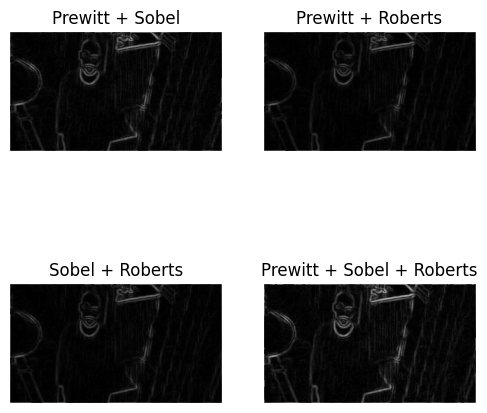

In [32]:
plt.figure(figsize=(6,6))

plt.subplot(2,2,1)
plt.title("Prewitt + Sobel")
plt.imshow(ps_normal, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.title("Prewitt + Roberts")
plt.imshow(pr_normal, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.title("Sobel + Roberts")
plt.imshow(sr_normal, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.title("Prewitt + Sobel + Roberts")
plt.imshow(psr_normal, cmap='gray')
plt.axis('off')

plt.show()

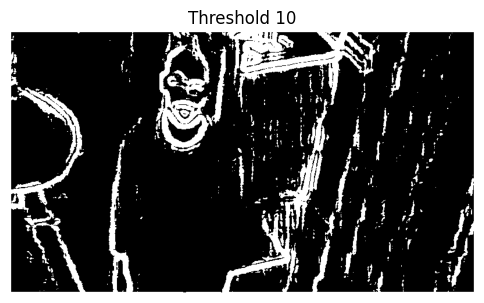

In [41]:
nilai_thresholding10 = 10 

tresh10 = np.where(prewitt >= nilai_thresholding10, 255, 0).astype(np.uint8)

plt.figure(figsize=(6,6))

plt.imshow(tresh10, cmap='gray')
plt.title("Threshold 10")
plt.axis('off')
plt.show()

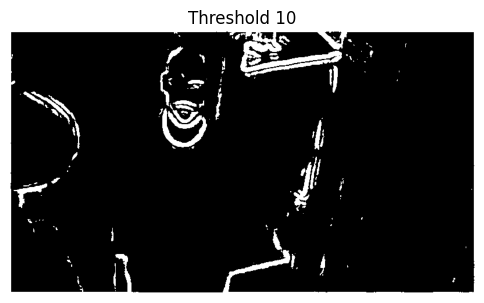

In [ ]:
nilai_thresholding20 = 20 

tresh20 = np.where(prewitt >= nilai_thresholding20, 255, 0).astype(np.uint8)

plt.figure(figsize=(6,6))

plt.imshow(tresh20, cmap='gray')
plt.title("Threshold 20")
plt.axis('off')
plt.show()

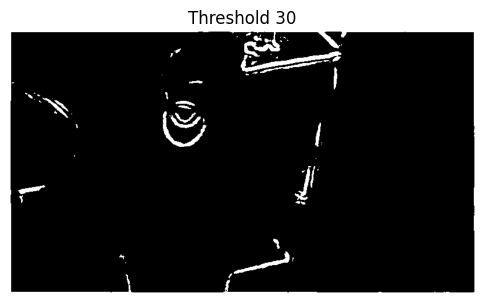

In [44]:
nilai_thresholding30 = 30 

tresh30 = np.where(prewitt >= nilai_thresholding30, 255, 0).astype(np.uint8)

plt.figure(figsize=(6,6))

plt.imshow(tresh30, cmap='gray')
plt.title("Threshold 30")
plt.axis('off')
plt.show()

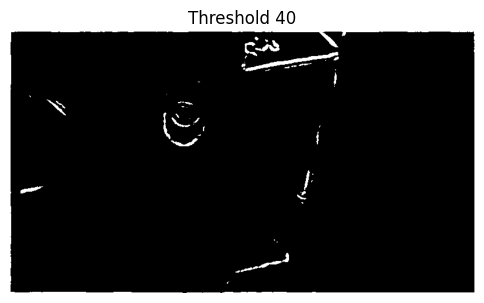

In [45]:
nilai_thresholding40 = 40

tresh40 = np.where(prewitt >= nilai_thresholding40, 255, 0).astype(np.uint8)

plt.figure(figsize=(6,6))

plt.imshow(tresh40, cmap='gray')
plt.title("Threshold 40")
plt.axis('off')
plt.show()

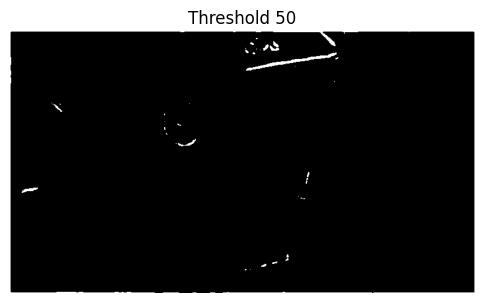

In [46]:
nilai_thresholding50 = 50

tresh50 = np.where(prewitt >= nilai_thresholding50, 255, 0).astype(np.uint8)

plt.figure(figsize=(6,6))

plt.imshow(tresh50, cmap='gray')
plt.title("Threshold 50")
plt.axis('off')
plt.show()

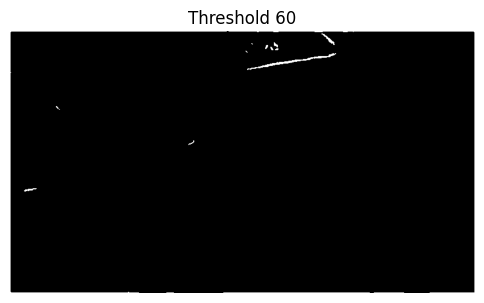

In [47]:
nilai_thresholding60 = 60

tresh60 = np.where(prewitt >= nilai_thresholding60, 255, 0).astype(np.uint8)

plt.figure(figsize=(6,6))

plt.imshow(tresh60, cmap='gray')
plt.title("Threshold 60")
plt.axis('off')
plt.show()

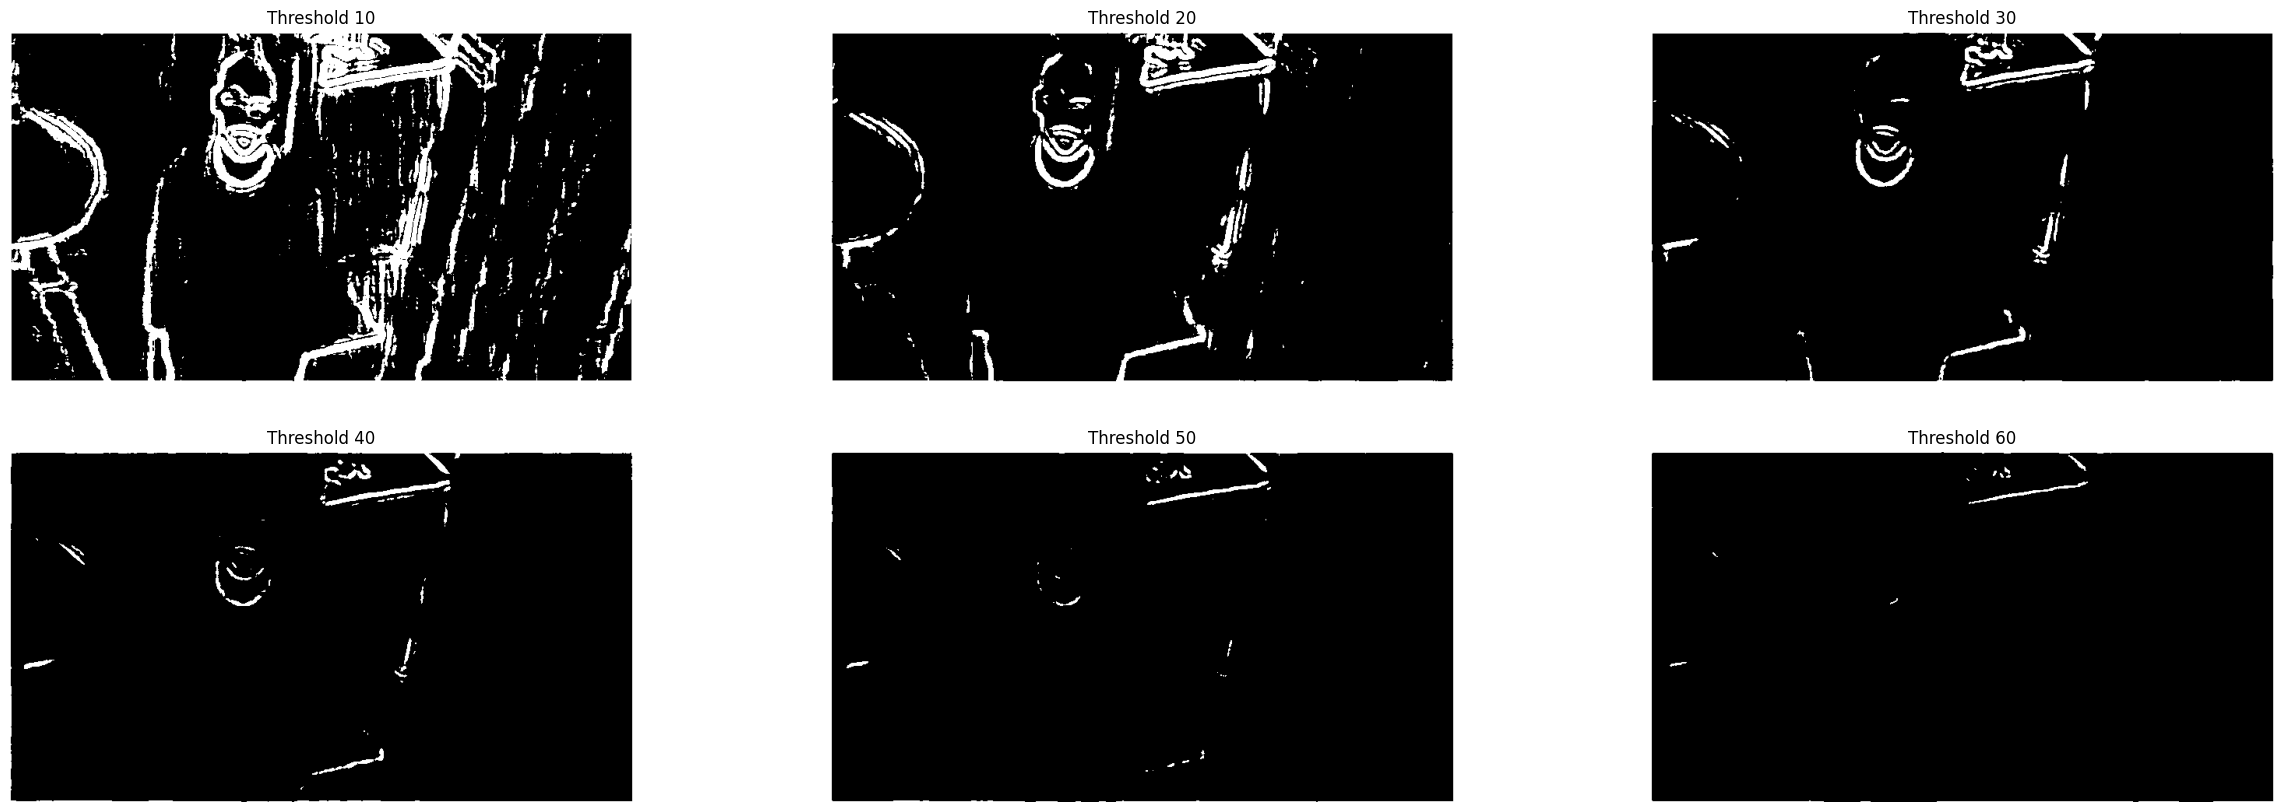

In [54]:
plt.figure(figsize=(30, 10))

plt.subplot(2,3,1)
plt.title("Threshold 10")
plt.imshow(tresh10, cmap='gray')
plt.axis('off')

plt.subplot(2,3,2)
plt.title("Threshold 20")
plt.imshow(tresh20, cmap='gray')
plt.axis('off')

plt.subplot(2,3,3)
plt.title("Threshold 30")
plt.imshow(tresh30, cmap='gray')
plt.axis('off')

plt.subplot(2,3,4)
plt.title("Threshold 40")
plt.imshow(tresh40, cmap='gray')
plt.axis('off')

plt.subplot(2,3,5)
plt.title("Threshold 50")
plt.imshow(tresh50, cmap='gray')
plt.axis('off')

plt.subplot(2,3,6)
plt.title("Threshold 60")
plt.imshow(tresh60, cmap='gray')
plt.axis('off')

plt.show()

Analisis jelaskan pengaruh penggunaan threshold. apa perbedaan mencolok dari threshold rendah dan tinggi? Berapa nilai Threshold paling bagus untuk kasus ini? berikan alasannya.
menurut saya pengaruh dari penggunanaan threshold itu adalah deteksi tepinya semakin tajam. Perbedaannya, semakin threshold rendah maka garis tepinya semakin tajam. sedangkan semakin threshold tinggi, maka garis tepinya semakin hilang. menurut saya nilai Threshold paling bagus untuk kasus ini adalah Threshold 10, karena garis tepinya masih jelas. kesimpulannya semakin kecil nilai Thresholdnya, maka deteksi tepinya semakin jelas.

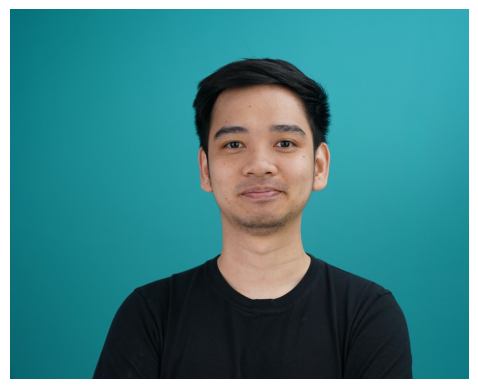

In [55]:
david = plt.imread('david.jpg')
plt.imshow(david)
plt.axis('off')
plt.show()

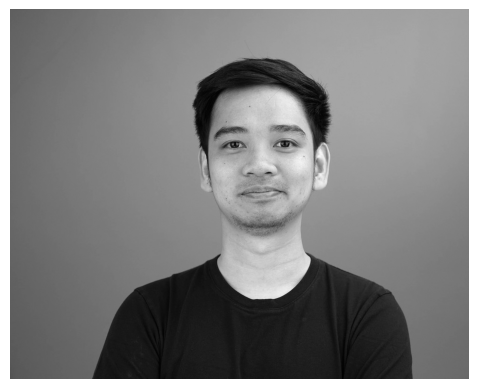

In [58]:
david_gray = cv2.cvtColor(david, cv2.COLOR_RGB2GRAY)
plt.imshow(david_gray, cmap='gray')
plt.axis('off')
plt.show()

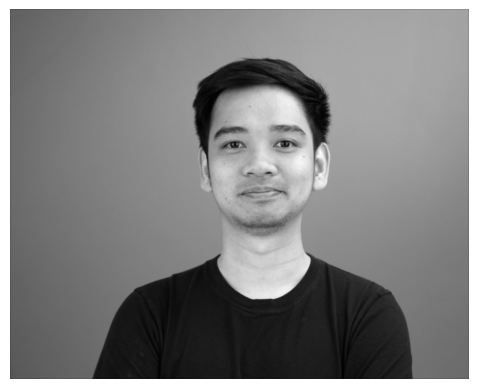

In [59]:
smooth_david = convolution (david_gray, kernelSmoothing)
sharp_david = convolution (david_gray, kernelSharpening)
sm_plus_sh_david = smooth_david + sharp_david

plt.imshow(sm_plus_sh_david, cmap='gray')
plt.axis('off')

plt.show()

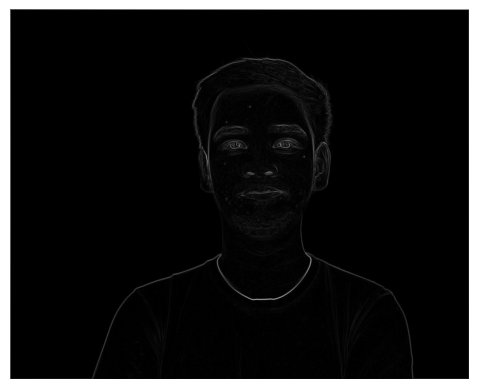

In [65]:
prewitt_david = edge(sm_plus_sh_david, prewittX, prewittY)
sobel_david = edge(sm_plus_sh_david, sobelX, sobelY)
robert_david = edge(sm_plus_sh_david, robertsX, robertsY)

plt.imshow(robert_david, cmap='gray')
plt.axis('off')

plt.show()